# Piloto 2026 - prueba M0 de pérdida aromática en equilibrio

## tl;dr

**Veredicto ejecutado:** `INFORMATIVE_NEGATIVE`.

Esta prueba elimina el parámetro libre de transferencia para contrastar dos modelos de partición y, en paralelo, corrige la base NTU del modelo con `kLa` líquido. El caso diagnóstico 26157-MIX-03 queda registrado en la salida ejecutada: `{"equilibrium_unifac": 24.237741552403676, "equilibrium_morakul": 48.77593614414894, "liquid_kla_unifac": 4.69209447263327, "observed_captured_ug": 614.557866106016}`.

El criterio de éxito exige mejorar al menos 30 % el error holdout de condensado para octanoato e isoamilo sin degradar más de 10 % el ajuste de vino.

## Context & Methods

### Key Assumptions

- La química líquida inicializa cada trayectoria; la primera muestra no entra al RMSE.
- Los holdouts completos son 26158 y 26211.
- El `rCO2` emitido proviene del modelo de CO2 validado previamente.
- `K=Cgas/Clíquido`; el modelo de equilibrio usa `lambda=K*(Qgas/VL)`.
- Morakul/Mouret representa composición mediante etanol y temperatura. Los coeficientes de acetatos provienen de mosto natural y los de octanoato de mosto sintético piloto.
- El tren de captura conserva las eficiencias históricas; por ello esta prueba aísla partición/transferencia, no valida todavía el condensador.
- Los puntos censurados se tratan como límites, no como ceros.

Fuentes primarias: Morakul et al. 2011, DOI 10.1016/j.procbio.2011.01.034; Mouret et al. 2014, DOI 10.1016/j.foodres.2014.02.044.

In [1]:
from pathlib import Path
import os
import sys
from IPython.display import display, Image

ROOT = Path.cwd()
while ROOT != ROOT.parent and not (ROOT / "fermentation_model").exists():
    ROOT = ROOT.parent
if not (ROOT / "fermentation_model").exists():
    raise RuntimeError("Execute from the repository or a descendant directory")
sys.path.insert(0, str(ROOT / "fermentation_model"))
from pilot_2026 import run_aroma_equilibrium_partition_test_2026 as analysis
result = analysis.load_results() if os.environ.get("PILOT_AROMA_REUSE_RESULTS") == "1" else analysis.run_analysis()
print("Resultados:", analysis.RESULTS_DIR.relative_to(ROOT))
print("Veredicto:", result["gate"]["verdict"])

Resultados: fermentation_model\pilot_2026\results\aroma_equilibrium_partition_test_2026
Veredicto: INFORMATIVE_NEGATIVE


## Data

,species,F1,F2_l_g,F3_kj_mol,F4_kj_l_mol_g,reference_temperature_k,source_matrix,parameter_source,doi,trap_efficiency
0,ethyl_acetate,-6.11,-0.0029,71.0,-0.4400,293.15,natural grape must,"Morakul et al. 2011, Process Biochemistry 46, ...",10.1016/j.procbio.2011.01.034,0.90
1,isoamyl_acetate,-3.98,-0.0096,49.0,-0.0017,293.15,natural grape must,"Morakul et al. 2011, Process Biochemistry 46, ...",10.1016/j.procbio.2011.01.034,0.88
2,ethyl_octanoate,-3.13,-0.0135,52.0,-0.0036,293.15,synthetic grape must; coefficients identified ...,"Mouret et al. 2014, Food Research Internationa...",10.1016/j.foodres.2014.02.044,0.85


,batch,pulse_time_h,timing_source
0,26134,58.421,chemical_density_linear_interpolation_1040
1,26135,60.248,chemical_density_linear_interpolation_1040
2,26136,45.587,chemical_density_linear_interpolation_1040
3,26157,63.118,chemical_density_linear_interpolation_1040
4,26158,61.016,chemical_density_linear_interpolation_1040
5,26159,79.462,chemical_density_linear_interpolation_1040
6,26210,62.780,chemical_density_linear_interpolation_1040
7,26211,63.551,chemical_density_linear_interpolation_1040
8,26212,42.087,chemical_density_linear_interpolation_1040


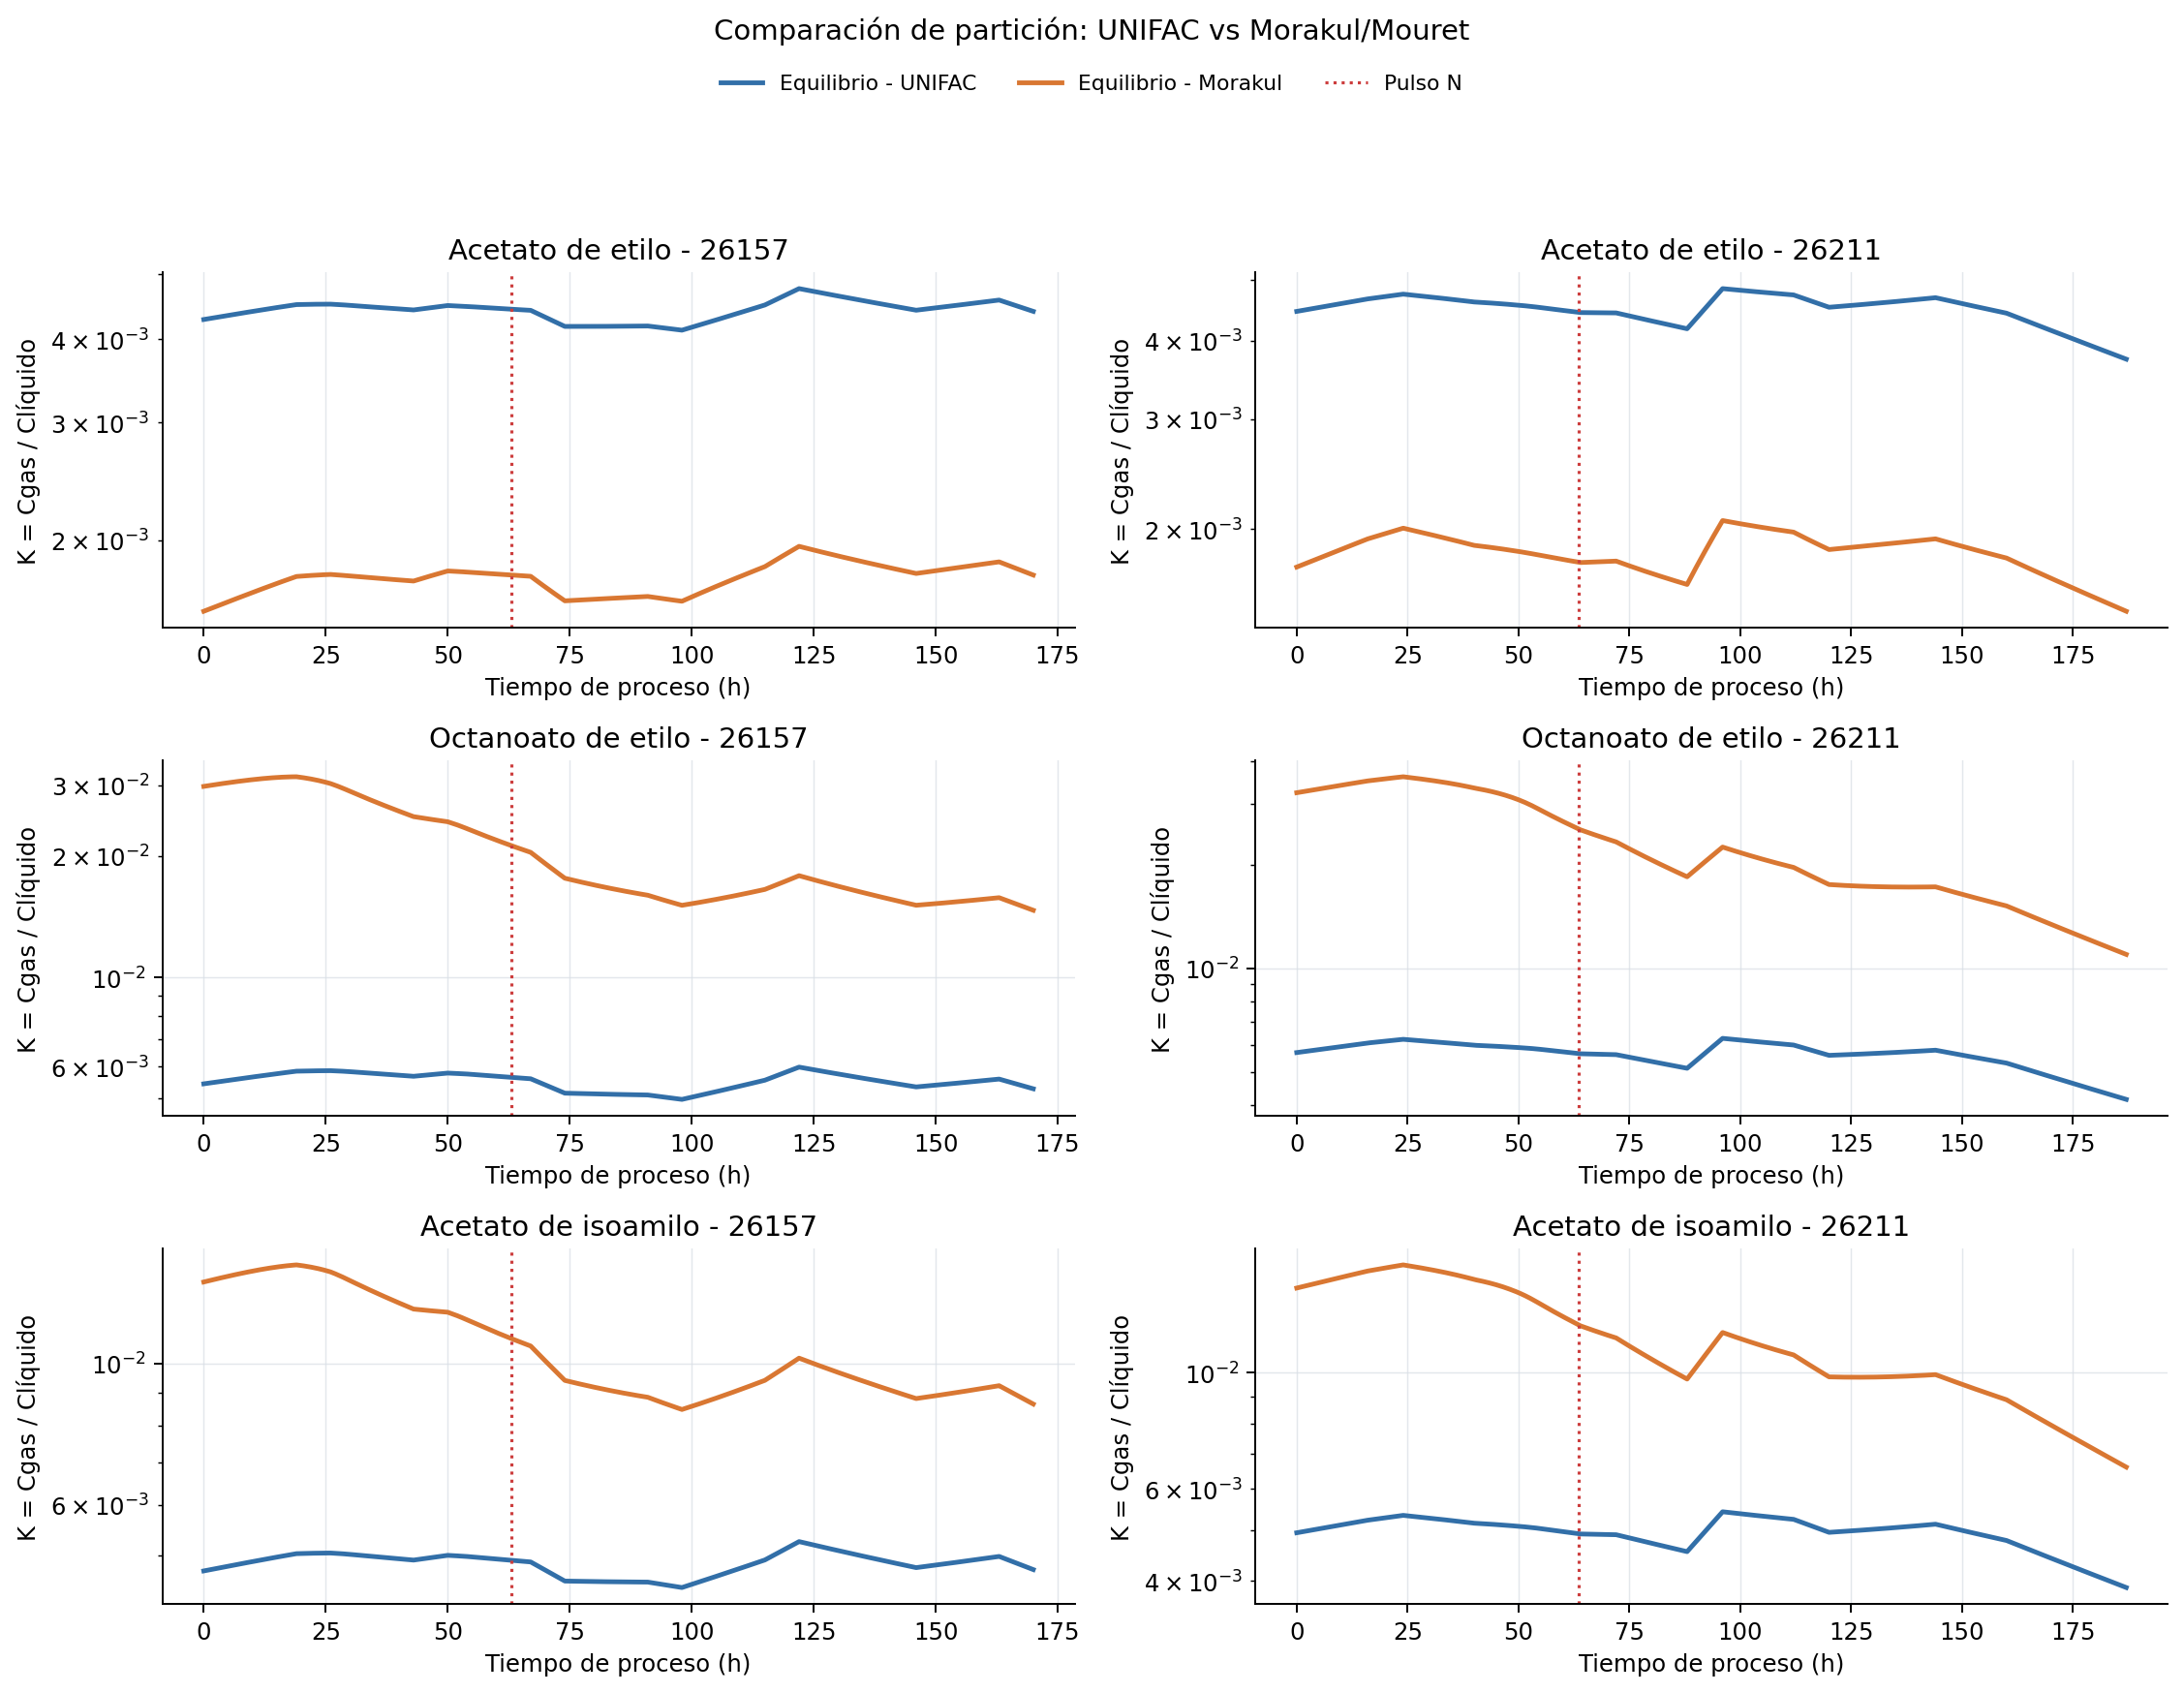

In [2]:
display(result["coefficients"])
display(result["pulses"][["batch", "pulse_time_h", "timing_source"]].round(3))
display(Image(filename=analysis.FIGURE_DIR / "partition_trajectories.png"))

## Results

,model_variant,species,domain,n_observed_scored,rmse,nrmse_over_mean,bias
7,equilibrium_morakul,ethyl_acetate,wine,11,12001.0455,1.0547,-10275.8854
9,equilibrium_morakul,ethyl_octanoate,wine,11,93.0817,1.1667,-77.9989
11,equilibrium_morakul,isoamyl_acetate,wine,11,1304.5309,1.1869,-1096.0356
19,equilibrium_unifac,ethyl_acetate,wine,11,12183.3423,1.0707,-10461.7577
21,equilibrium_unifac,ethyl_octanoate,wine,11,92.2869,1.1567,-77.1334
23,equilibrium_unifac,isoamyl_acetate,wine,11,1299.2728,1.1821,-1090.5153
31,liquid_kla_unifac,ethyl_acetate,wine,11,5556.1656,0.4883,-2619.2696
33,liquid_kla_unifac,ethyl_octanoate,wine,11,48.4494,0.6073,-21.0350
35,liquid_kla_unifac,isoamyl_acetate,wine,11,725.2074,0.6598,-426.4406
43,equilibrium_morakul,ethyl_acetate,condensate,0,NaN,NaN,NaN


,model_variant,species,domain,rmse,benchmark_rmse,relative_change_vs_historical
0,equilibrium_unifac,ethyl_acetate,wine,12183.3423,5550.2417,1.1951
1,equilibrium_unifac,ethyl_acetate,condensate,NaN,NaN,NaN
2,equilibrium_unifac,ethyl_octanoate,wine,92.2869,48.3976,0.9069
3,equilibrium_unifac,ethyl_octanoate,condensate,838.8216,846.3413,-0.0089
4,equilibrium_unifac,isoamyl_acetate,wine,1299.2728,724.2755,0.7939
5,equilibrium_unifac,isoamyl_acetate,condensate,3069.4842,3072.3317,-0.0009
6,equilibrium_morakul,ethyl_acetate,wine,12001.0455,5550.2417,1.1623
7,equilibrium_morakul,ethyl_acetate,condensate,NaN,NaN,NaN
8,equilibrium_morakul,ethyl_octanoate,wine,93.0817,48.3976,0.9233
9,equilibrium_morakul,ethyl_octanoate,condensate,827.5727,846.3413,-0.0222


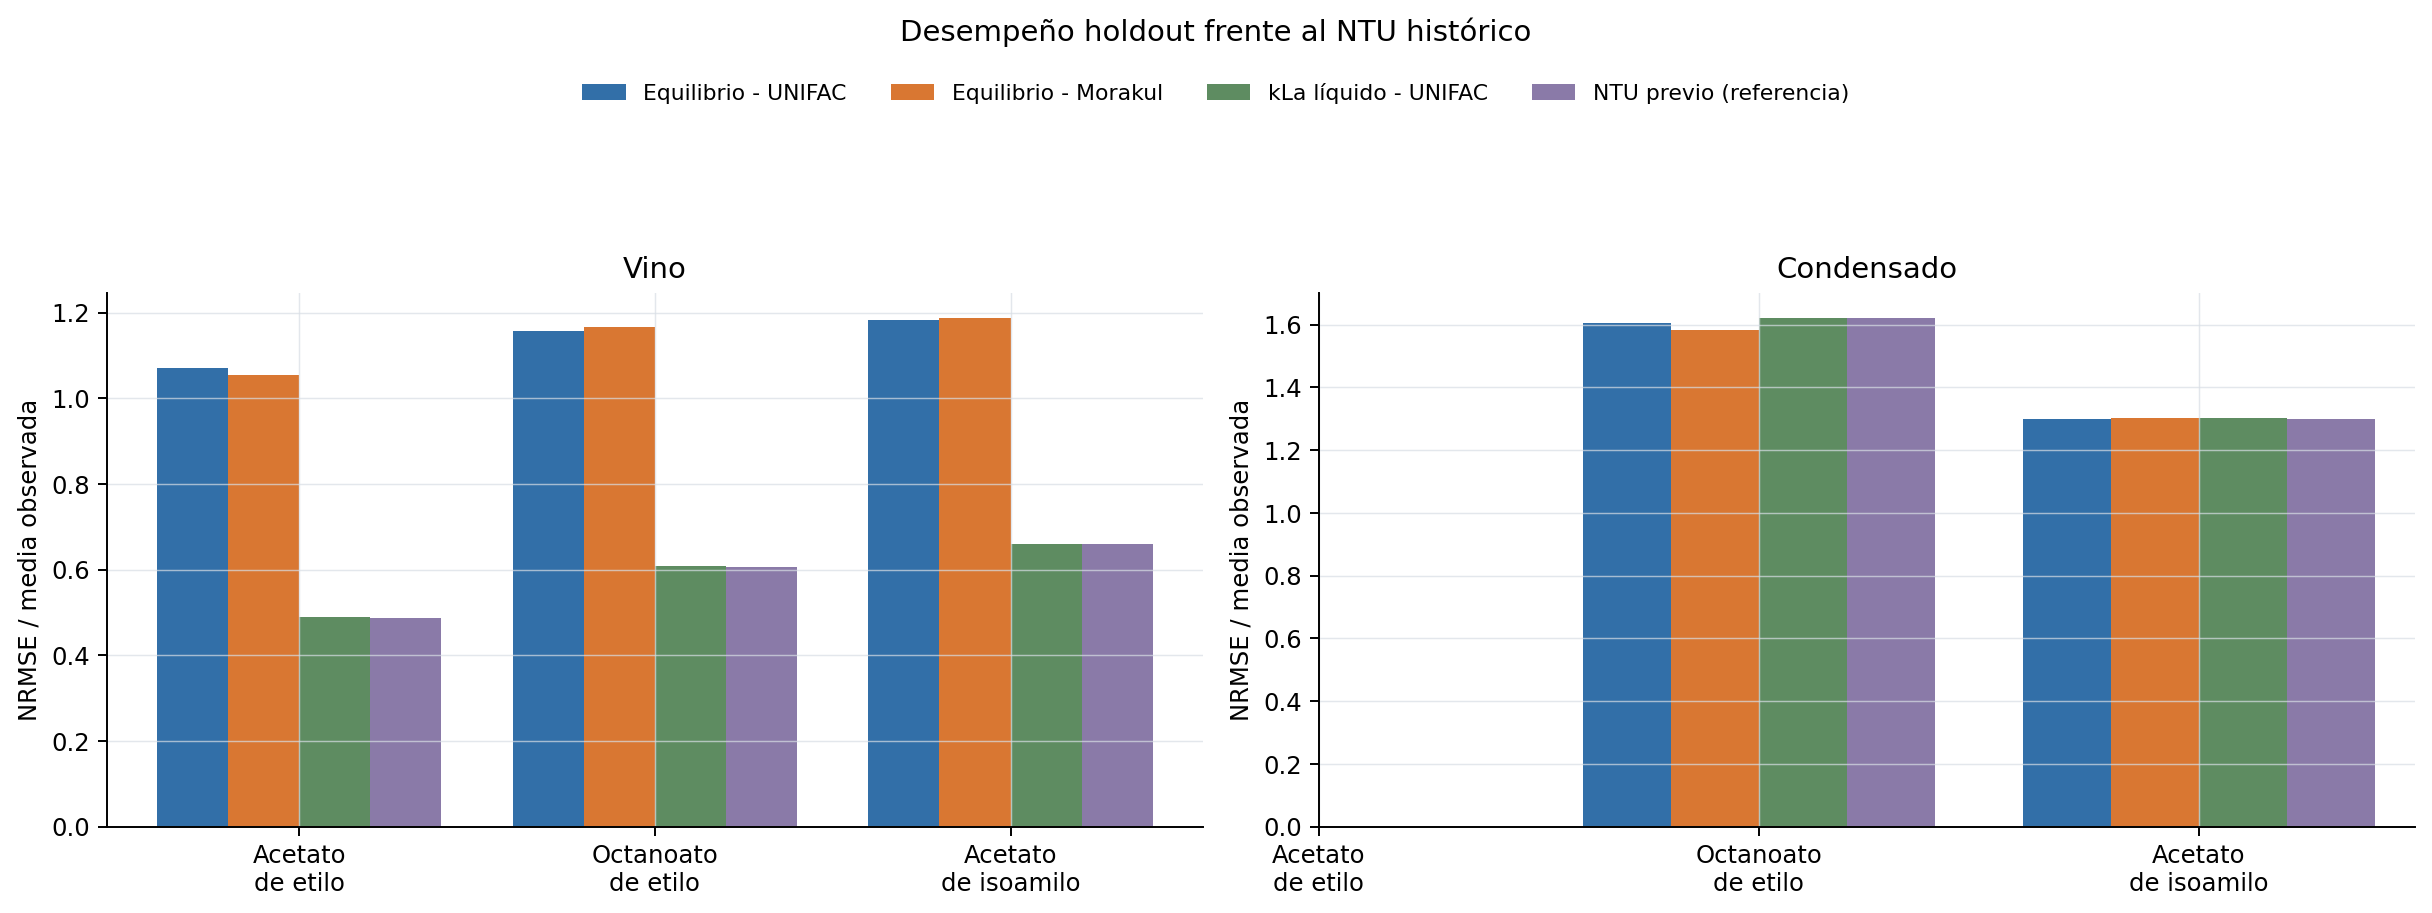

In [3]:
holdout = result["metrics"].query("fit_scope == 'calibration_only' and role == 'holdout'")
display(holdout[["model_variant", "species", "domain", "n_observed_scored", "rmse", "nrmse_over_mean", "bias"]].round(4))
display(result["comparison"].round(4))
display(Image(filename=analysis.FIGURE_DIR / "holdout_metric_comparison.png"))

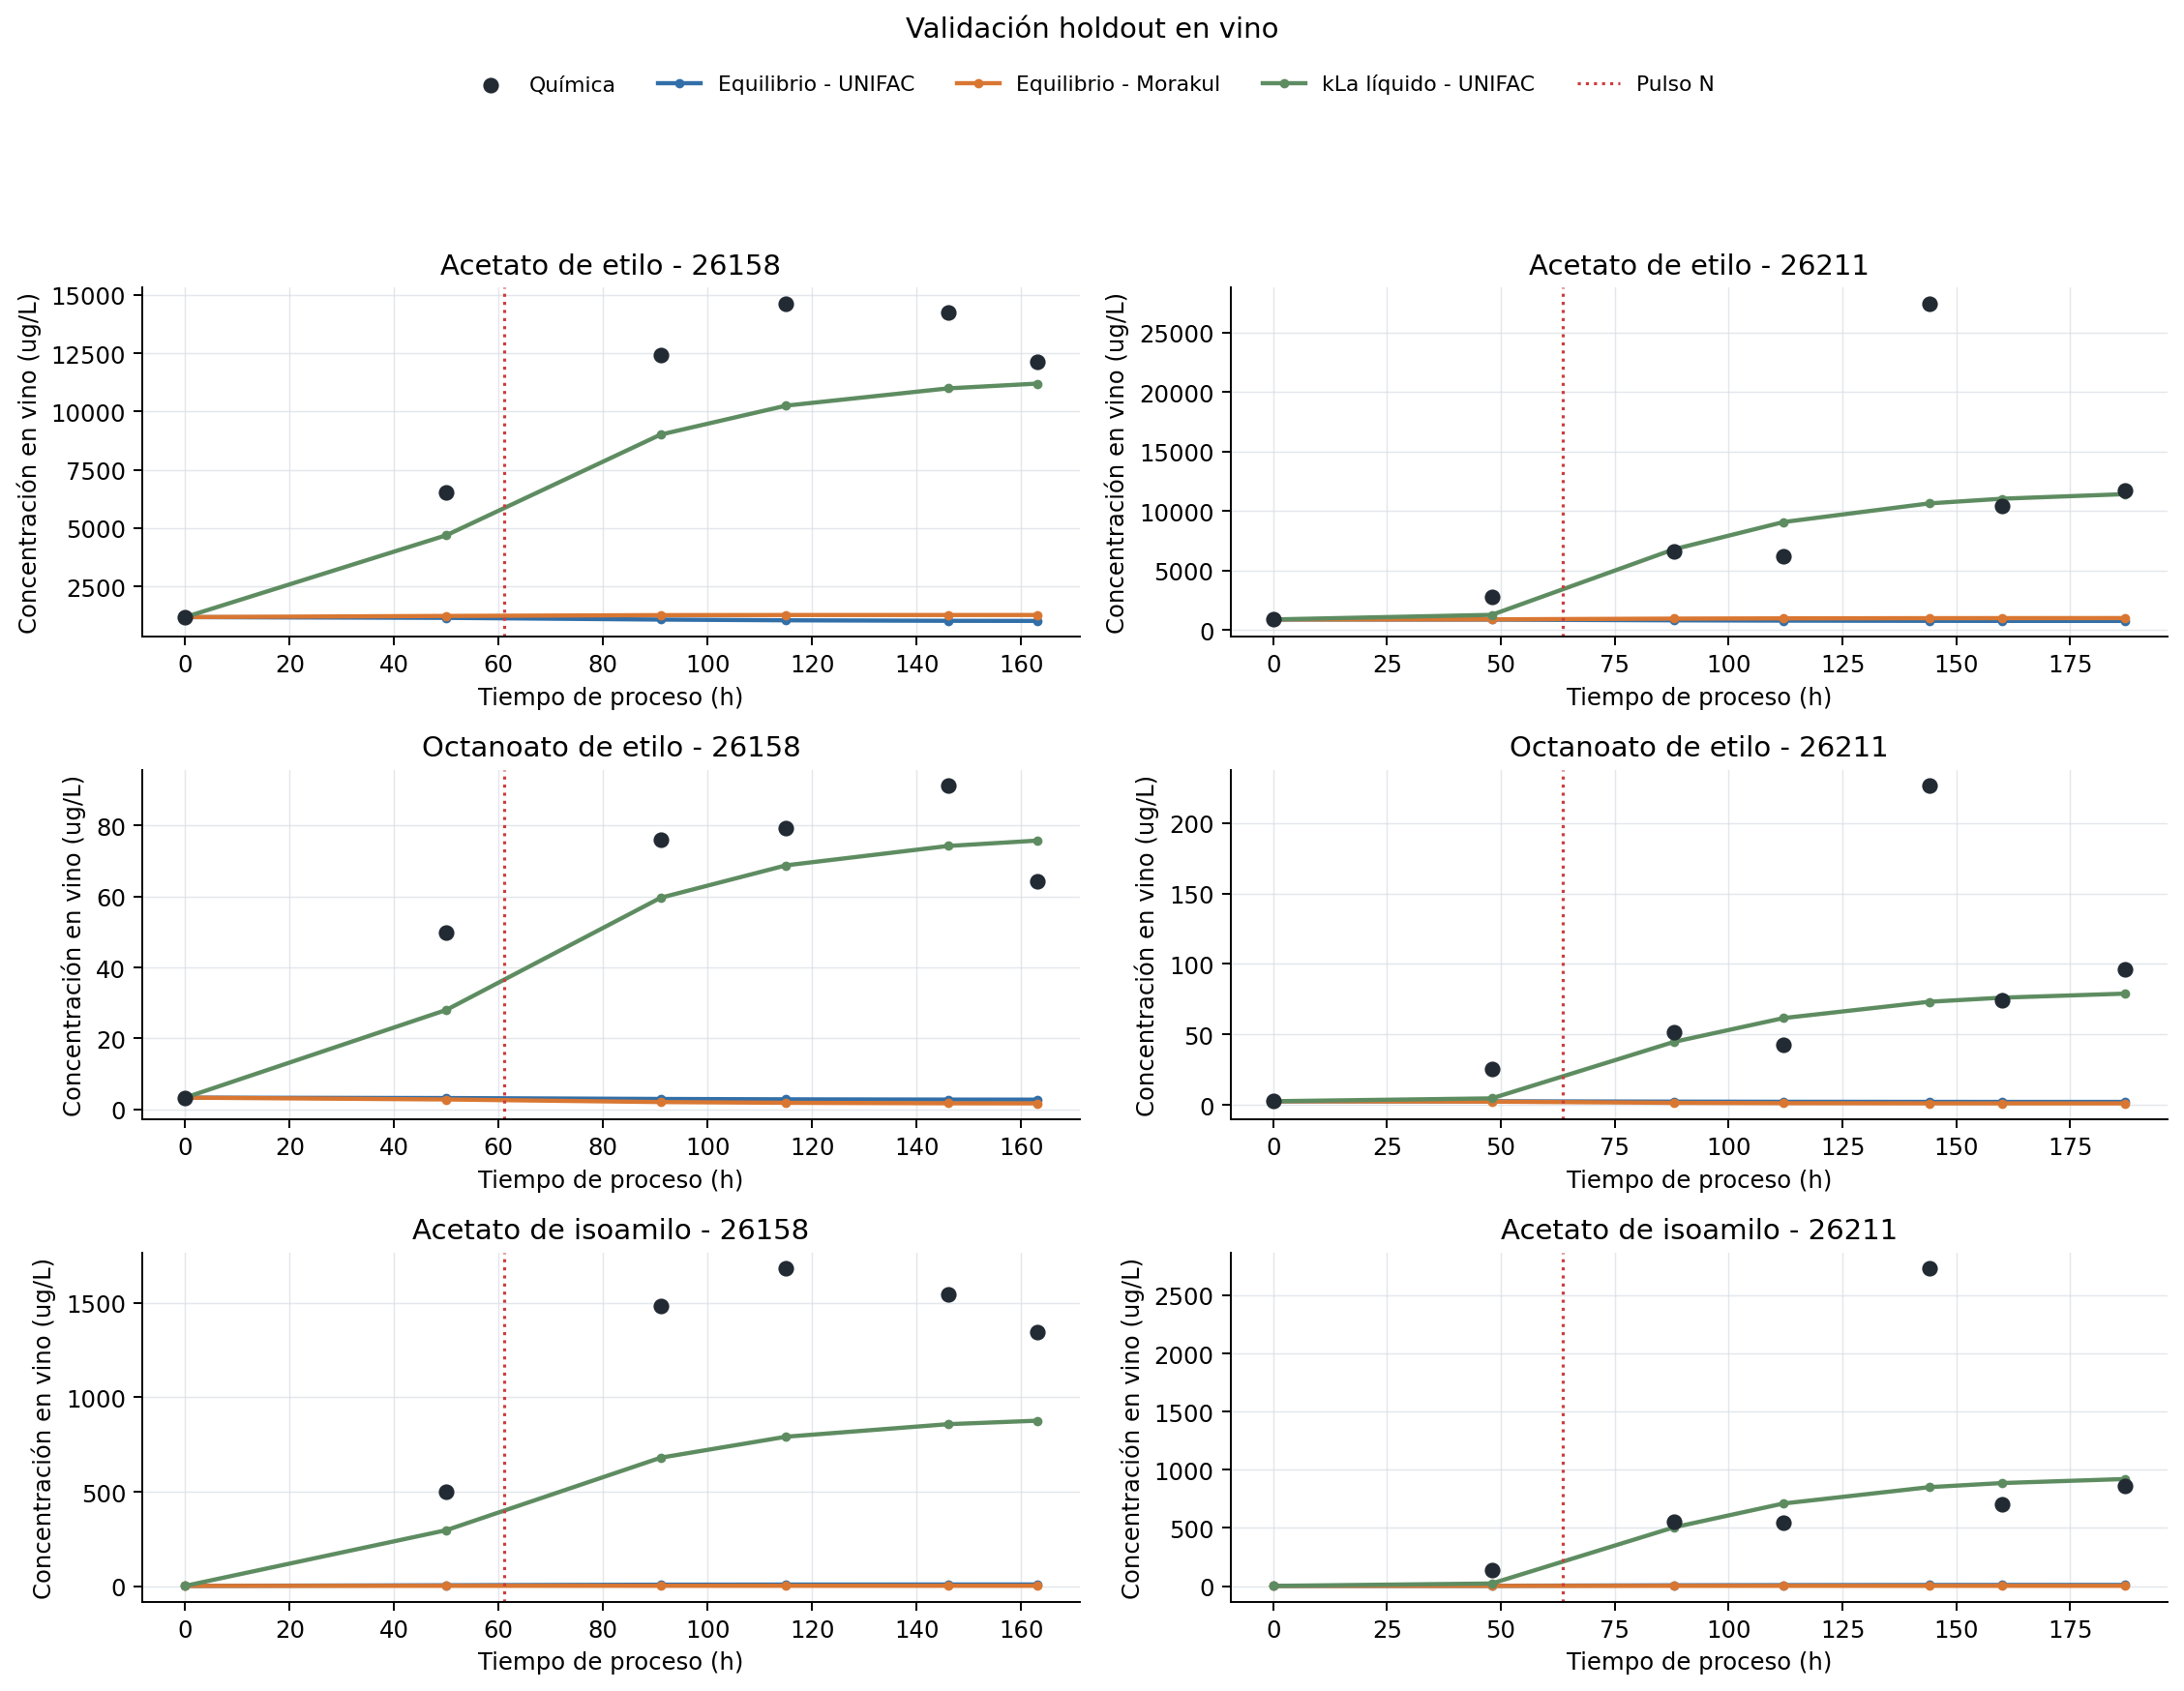

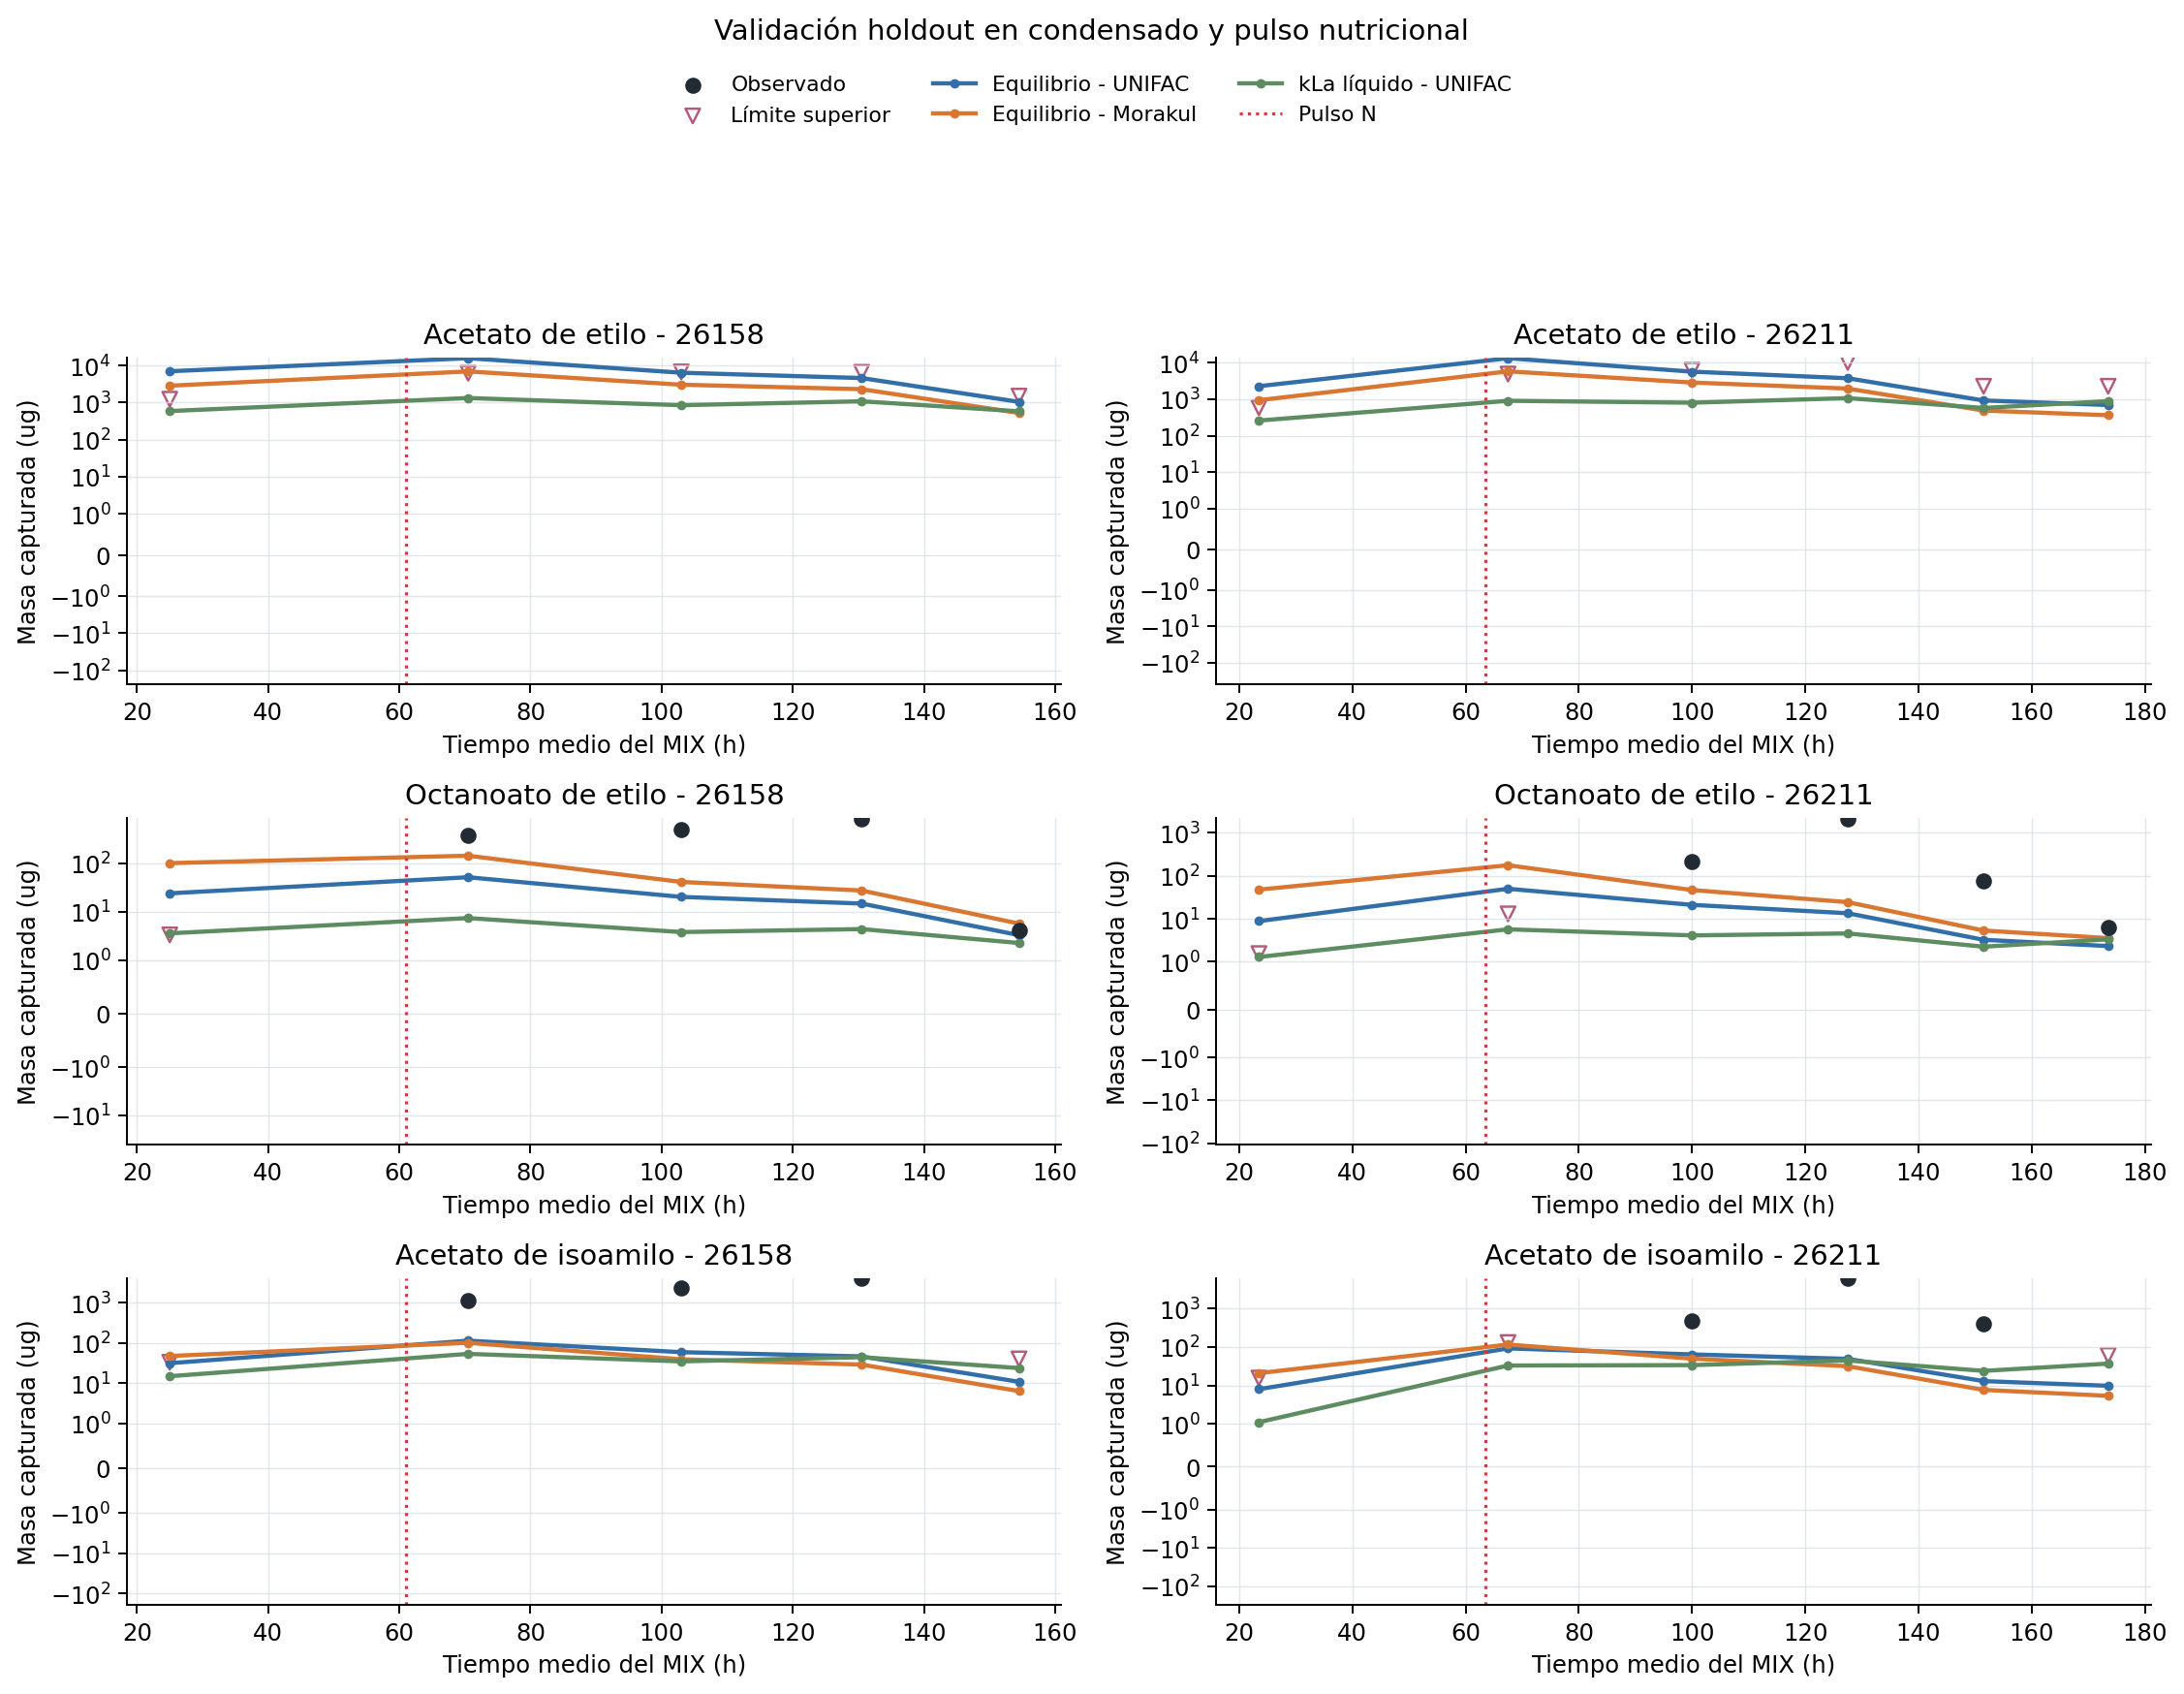

In [4]:
display(Image(filename=analysis.FIGURE_DIR / "holdout_wine_predictions.png"))
display(Image(filename=analysis.FIGURE_DIR / "holdout_condensate_predictions.png"))

## Transfer and identifiability checks

,model_variant,fit_scope,species,objective,objective_per_observation,converged_multistarts,active_bound_fraction,weak_parameters,loss_separately_identified,loss_parameter_fixed_by_physics,loss_model
0,equilibrium_unifac,calibration_only,ethyl_acetate,1733.62013,36.11709,9,0.0,formation_growth_ug_per_g_sugar;formation_stat...,NaN,True,equilibrium_gas_liquid_partition
1,equilibrium_unifac,calibration_only,ethyl_octanoate,1869.51195,38.94817,11,0.5,formation_growth_ug_per_g_sugar;formation_stat...,NaN,True,equilibrium_gas_liquid_partition
2,equilibrium_unifac,calibration_only,isoamyl_acetate,654.68853,13.63934,12,0.0,formation_growth_ug_per_g_sugar;formation_stat...,NaN,True,equilibrium_gas_liquid_partition
3,equilibrium_unifac,all_data,ethyl_acetate,2550.41196,35.42239,10,0.0,formation_growth_ug_per_g_sugar;formation_stat...,NaN,True,equilibrium_gas_liquid_partition
4,equilibrium_unifac,all_data,ethyl_octanoate,2843.43967,39.49222,12,0.5,formation_growth_ug_per_g_sugar;formation_stat...,NaN,True,equilibrium_gas_liquid_partition
5,equilibrium_unifac,all_data,isoamyl_acetate,1010.94674,14.04093,12,0.0,formation_growth_ug_per_g_sugar;formation_stat...,NaN,True,equilibrium_gas_liquid_partition
6,equilibrium_morakul,calibration_only,ethyl_acetate,517.29117,10.77690,12,0.0,formation_growth_ug_per_g_sugar;formation_stat...,NaN,True,equilibrium_gas_liquid_partition
7,equilibrium_morakul,calibration_only,ethyl_octanoate,26281.07929,547.52249,12,1.0,formation_growth_ug_per_g_sugar;formation_stat...,NaN,True,equilibrium_gas_liquid_partition
8,equilibrium_morakul,calibration_only,isoamyl_acetate,673.35977,14.02833,11,0.0,formation_growth_ug_per_g_sugar;formation_stat...,NaN,True,equilibrium_gas_liquid_partition
9,equilibrium_morakul,all_data,ethyl_acetate,775.31057,10.76820,11,0.0,formation_growth_ug_per_g_sugar;formation_stat...,NaN,True,equilibrium_gas_liquid_partition


,model_variant,fit_scope,species,parameter,estimate,lower_bound,upper_bound,active_bound,std_log_local
6,equilibrium_unifac,all_data,ethyl_acetate,formation_growth_ug_per_g_sugar,0.042775,0.00010,10000.0,False,14.832912
7,equilibrium_unifac,all_data,ethyl_acetate,formation_stationary_ug_per_g_sugar,0.023789,0.00010,10000.0,False,14.767303
8,equilibrium_unifac,all_data,ethyl_octanoate,formation_growth_ug_per_g_sugar,0.000137,0.00010,10000.0,False,15.650807
9,equilibrium_unifac,all_data,ethyl_octanoate,formation_stationary_ug_per_g_sugar,0.000100,0.00010,10000.0,True,15.449355
10,equilibrium_unifac,all_data,isoamyl_acetate,formation_growth_ug_per_g_sugar,0.034411,0.00010,10000.0,False,7.526690
11,equilibrium_unifac,all_data,isoamyl_acetate,formation_stationary_ug_per_g_sugar,0.080702,0.00010,10000.0,False,1.290788
18,equilibrium_morakul,all_data,ethyl_acetate,formation_growth_ug_per_g_sugar,0.523649,0.00010,10000.0,False,8.049570
19,equilibrium_morakul,all_data,ethyl_acetate,formation_stationary_ug_per_g_sugar,1.746852,0.00010,10000.0,False,2.539655
20,equilibrium_morakul,all_data,ethyl_octanoate,formation_growth_ug_per_g_sugar,0.000100,0.00010,10000.0,True,58.209356
21,equilibrium_morakul,all_data,ethyl_octanoate,formation_stationary_ug_per_g_sugar,0.000100,0.00010,10000.0,True,51.824073


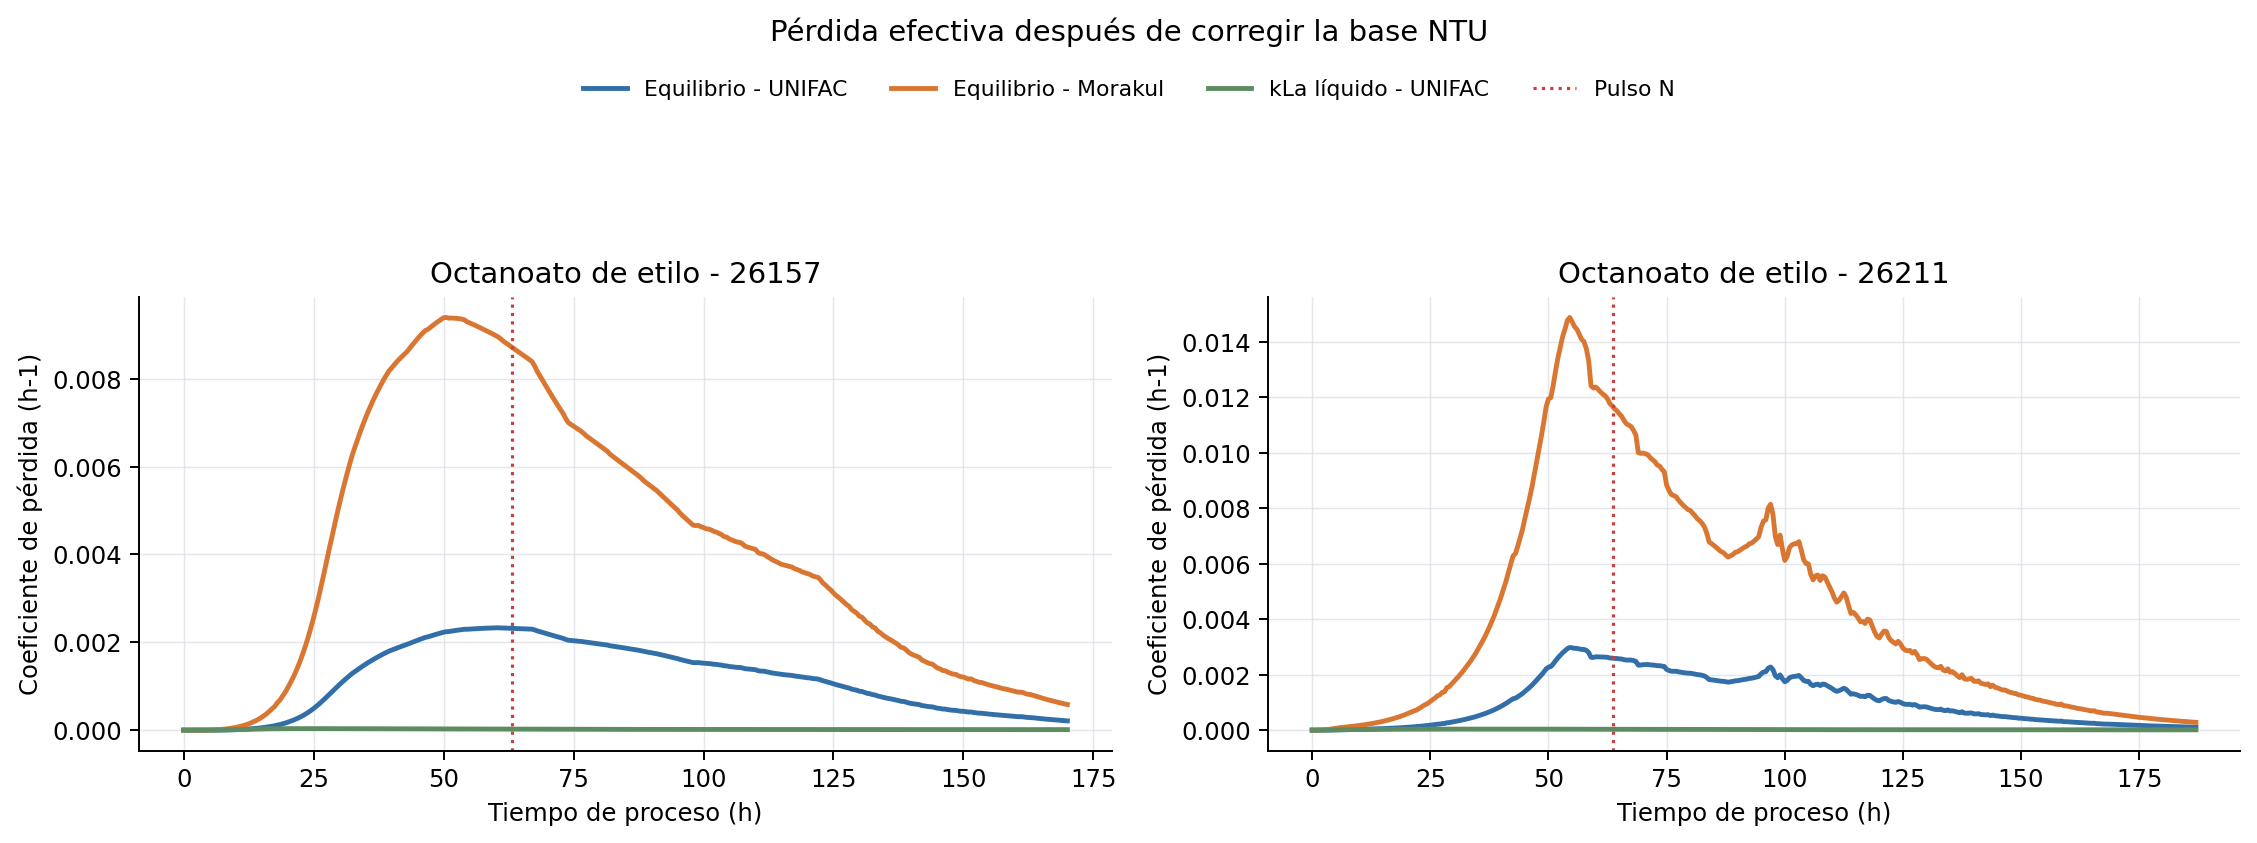

In [5]:
display(result["validation"].round(5))
display(result["parameters"].query("fit_scope == 'all_data'").round(6))
display(Image(filename=analysis.FIGURE_DIR / "ethyl_octanoate_effective_loss.png"))

## Takeaways

- Si equilibrio-Morakul mejora condensado y respeta el guardrail de vino, el siguiente paso es el estado de headspace/trampa.
- Si el modelo sigue fallando en MIX-04 o sobrepasa el techo calculado con química interpolada, el bloqueo está en producción temporal, captura o resolución de muestreo, no en un `kLa` adicional.
- Un `kLa` corregido que caiga al límite inferior indica que el optimizador intenta reconstruir artificialmente la penalización histórica.
- Ningún resultado de acetato de etilo permite declarar identificabilidad de pérdida porque todos sus condensados están censurados.

In [6]:
assert result["gate"]["verdict"] in {"PASS", "INFORMATIVE_NEGATIVE", "COMPUTATIONAL_FAILURE"}
assert len(result["figures"]) == 5
print("Notebook ejecutado sin errores.")
print("Figuras embebidas:", len(result["figures"]))
print("Gate:", result["gate"]["verdict"])

Notebook ejecutado sin errores.
Figuras embebidas: 5
Gate: INFORMATIVE_NEGATIVE
